## Feature Extraction, Clustering, and Dimensionality Reduction using PCA

In this section, we will perform feature extraction and clustering on our dataset. Additionally, we will use Principal Component Analysis (PCA) to reduce the dimensionality of the data.

Our data consists of signals captured by devices, which may contain noise. Therefore, we will create two datasets:
1. Dataset without using the Butterworth lowpass filter
2. Dataset using the Butterworth lowpass filter

We will then evaluate which dataset performs better in modeling.

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from helper.tools import LowPassFilter, PrincipalComponentAnalysis
from sklearn.cluster import KMeans


# plot settings
plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (20, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams["lines.linewidth"] = 2


In [148]:
# load data
df = pd.read_pickle('../processed_data/dataInterpolated.pkl')
columns = list(df.columns[1:7])
columns_acc = list(df.columns[1:4])
columns_gyro = list(df.columns[4:7])

## No Filtering Dataset

### **Principal Component Analysis (PCA)**

In [149]:
PCA = PrincipalComponentAnalysis()
df_pca_NoFilter = df.copy()

values = PCA.determine_pc_explained_variance(df_pca_NoFilter, columns)

#### ELBOW TECHNIQUE

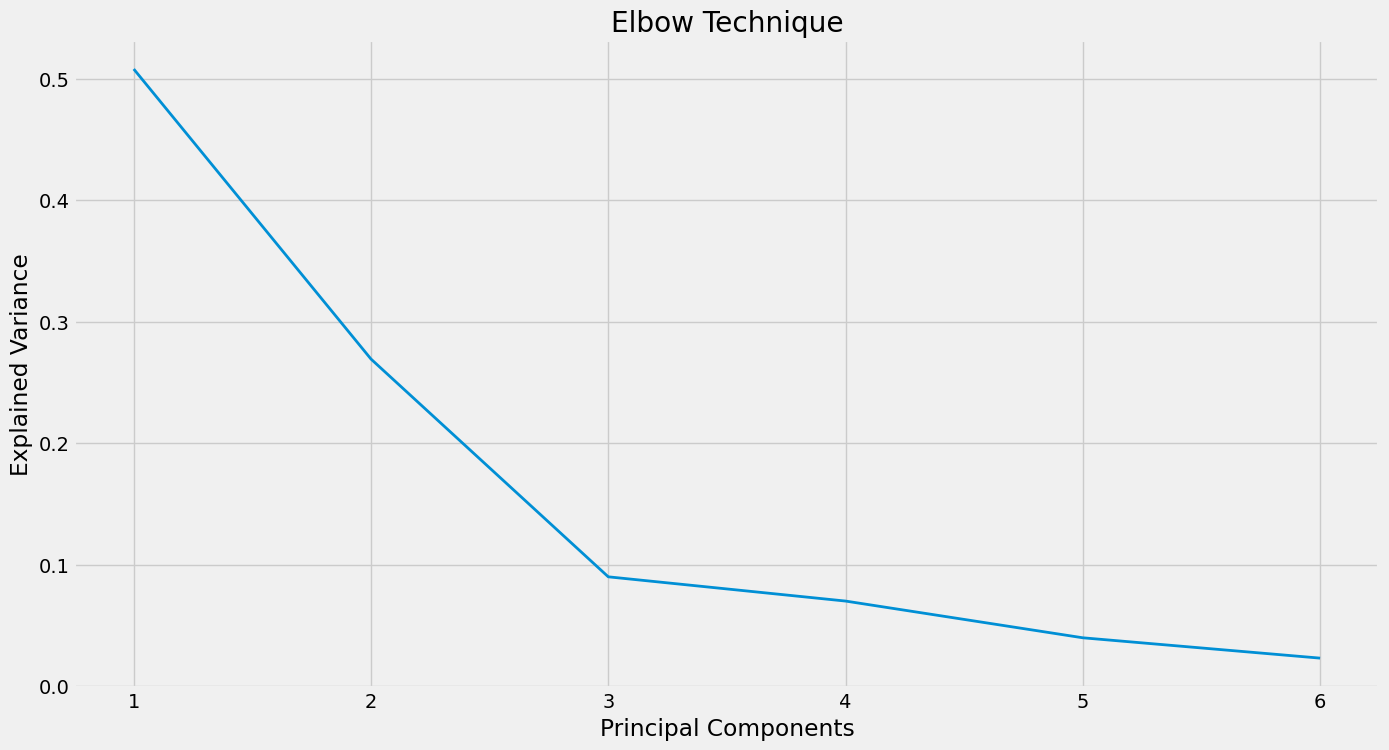

In [150]:
# Elbow technique
plt.figure(figsize=(15, 8))
plt.plot(range(1, len(columns) + 1), values)
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance")
plt.title("Elbow Technique")
plt.show()

In [151]:
df_pca_NoFilter = PCA.apply_pca(df_pca_NoFilter, columns, 3)

#### **SQUERED**

In [152]:
df_squered_NoFilter = df_pca_NoFilter.copy()
Accelerometer_r = df_squered_NoFilter["Accelerometer_x"]**2 + df_squered_NoFilter["Accelerometer_y"]**2 + df_squered_NoFilter["Accelerometer_z"]**2
Gyroscope_r = df_squered_NoFilter["Gyroscope_x"]**2 + df_squered_NoFilter["Gyroscope_y"]**2 + df_squered_NoFilter["Gyroscope_z"]**2

df_squered_NoFilter["Accelerometer_r"] = np.sqrt(Accelerometer_r)
df_squered_NoFilter["Gyroscope_r"] = np.sqrt(Gyroscope_r)

#### PCA and SQUARE PLOTS

array([<Axes: >, <Axes: >], dtype=object)

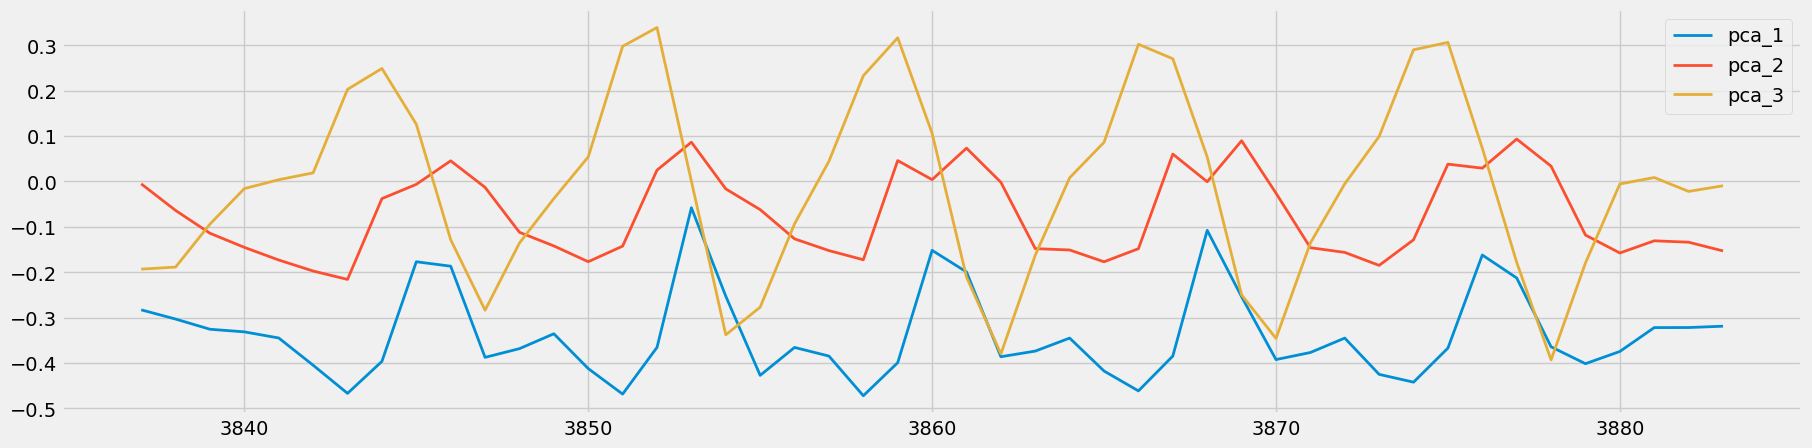

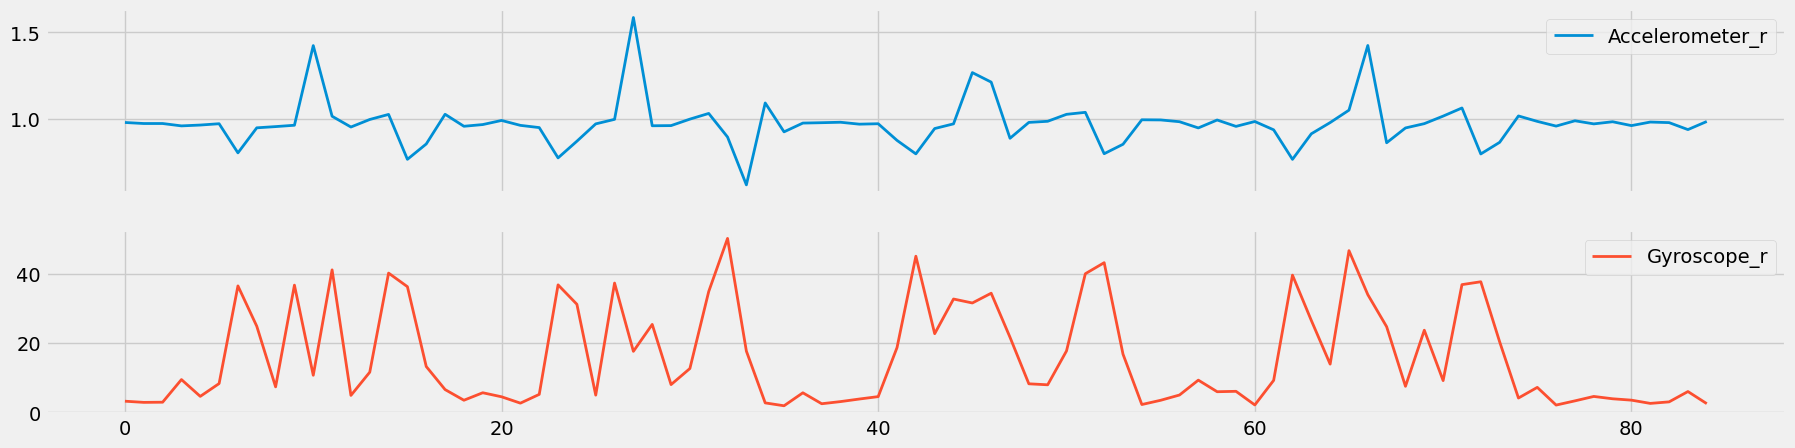

In [153]:
# in this case wee see that the data have noise
subset = df_pca_NoFilter[df_pca_NoFilter["Set"] == 35]
subset[["pca_1", "pca_2", "pca_3"]].plot()

subset = df_squered_NoFilter[df_squered_NoFilter["Set"] == 30]
subset[["Accelerometer_r", "Gyroscope_r"]].plot(subplots=True)

#### **CLUSTERING**

- acceletrator_colums

In [154]:
df_cluster_NoFilter = df_squered_NoFilter.copy()
kvalues = range(1, 10)
inertia_acc = []

for k in kvalues:
    subset = df_cluster_NoFilter[columns_acc]
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=0)
    cluster_labels = kmeans.fit_predict(subset) # fit_predict is used to fit the model and predict the cluster labels
    inertia_acc.append(kmeans.inertia_) # inertia is the sum of squared distances of samples to their closest cluster center

# using elbow technique to determine the number of clusters
kmeans = KMeans(n_clusters=5, n_init=20, random_state=0)
subset = df_cluster_NoFilter[columns_acc]
df_cluster_NoFilter["cluster_acc"] = kmeans.fit_predict(subset)


- gyroscope_colums

In [155]:
inertia_gyr = []
for k in kvalues:
    subset = df_cluster_NoFilter[columns_gyro]
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=0)
    cluster_labels = kmeans.fit_predict(subset) # fit_predict is used to fit the model and predict the cluster labels
    inertia_gyr.append(kmeans.inertia_) # inertia is the sum of squared distances of samples to their closest cluster center

# using elbow technique to determine the number of clusters
kmeans = KMeans(n_clusters=5, n_init=20, random_state=0)
subset = df_cluster_NoFilter[columns_gyro]
df_cluster_NoFilter["cluster_gyro"] = kmeans.fit_predict(subset)


#### **PLOTS**

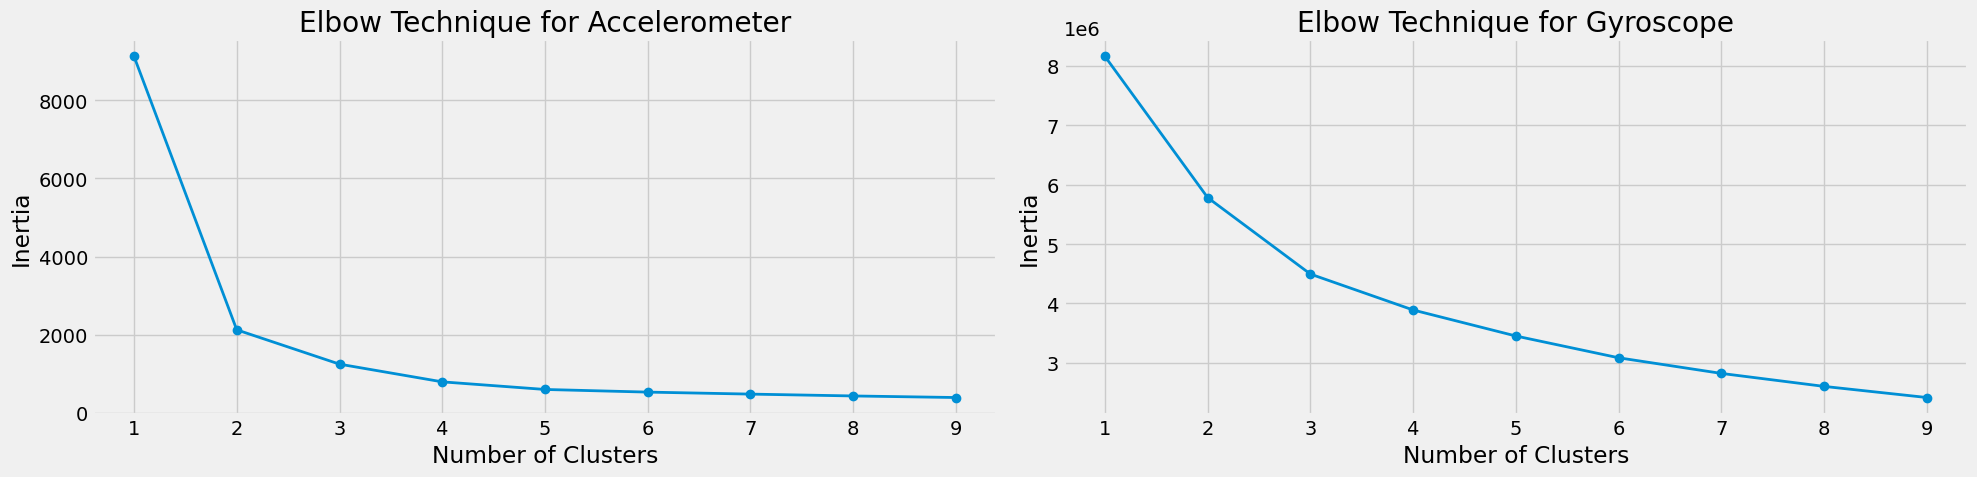

In [156]:
# Accelerometer
plt.subplot(1, 2, 1)
plt.plot(kvalues, inertia_acc, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Technique for Accelerometer")

# Gyroscope
plt.subplot(1, 2, 2)
plt.plot(kvalues, inertia_gyr, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Technique for Gyroscope")

plt.tight_layout()
plt.show()

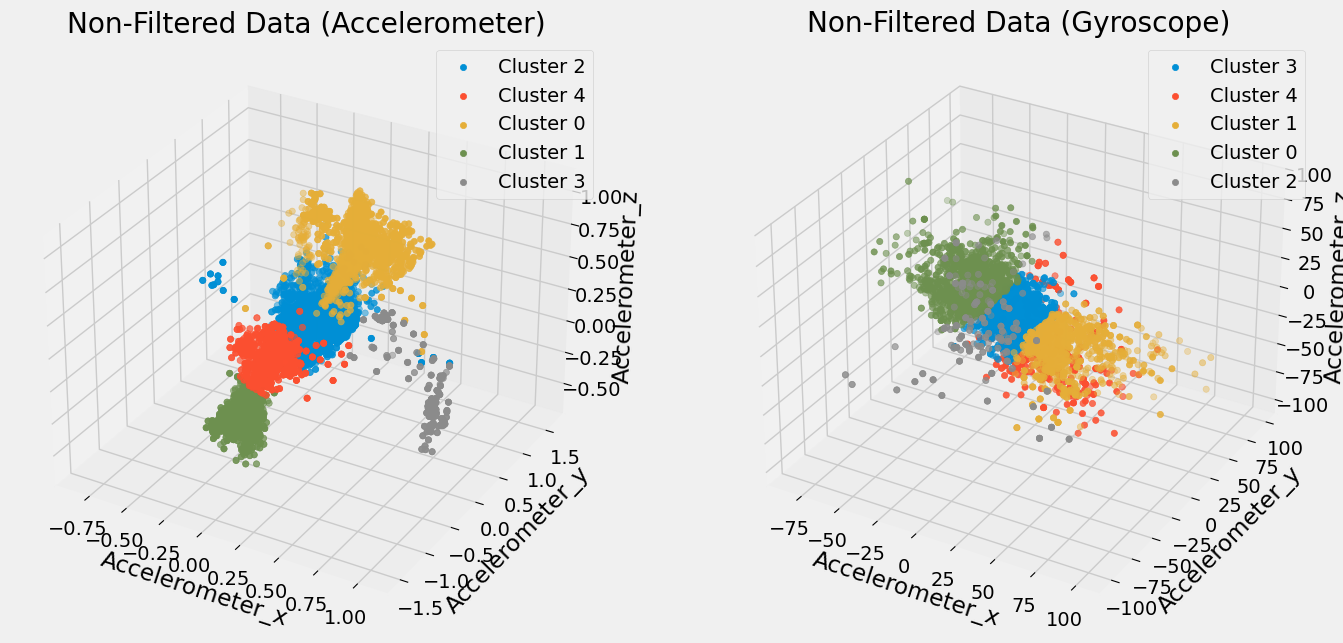

In [157]:
# plot the clusters for non-filtered data
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(121, projection='3d')
for c in df_cluster_NoFilter["cluster_acc"].unique():
    subset = df_cluster_NoFilter[df_cluster_NoFilter["cluster_acc"] == c]
    ax.scatter(subset["Accelerometer_x"], subset["Accelerometer_y"], subset["Accelerometer_z"], label=f"Cluster {c}")
ax.set_xlabel("Accelerometer_x")
ax.set_ylabel("Accelerometer_y")
ax.set_zlabel("Accelerometer_z")
ax.set_title("Non-Filtered Data (Accelerometer)")
plt.legend()

# plot the clusters for filtered data
ax = fig.add_subplot(122, projection='3d')
for c in df_cluster_NoFilter["cluster_gyro"].unique():
    subset = df_cluster_NoFilter[df_cluster_NoFilter["cluster_gyro"] == c]
    ax.scatter(subset["Gyroscope_x"], subset["Gyroscope_y"], subset["Gyroscope_z"], label=f"Cluster {c}")
ax.set_xlabel("Accelerometer_x")
ax.set_ylabel("Accelerometer_y")
ax.set_zlabel("Accelerometer_z")
ax.set_title("Non-Filtered Data (Gyroscope)")
plt.legend()

plt.show()

## **Filtering the dataset**

- We will use a low pass filter to remove the noise

In [158]:
df_filter = df.copy()
LowPass = LowPassFilter()

In [159]:
# wee see that the device is based on 200 ms
# so to for one second = 1000 ms
# 1000/200 = 5 smaples so the frequency is 5

fs = 1000/200
cutoff = 0.8 # how many hz we want to keep

# apply the filter to all columns
for col in columns:
    df_filter = LowPass.low_pass_filter(df_filter, col, fs, cutoff, order=5)
    df_filter[col] = df_filter[col + "_lowpass"] # overwriting the original column with the low pass filter column
    df_filter.drop(columns=[col + "_lowpass"], inplace=True) # drop the low pass filter column


### **Plots For all the filtered Columns**

#### - **PCA**

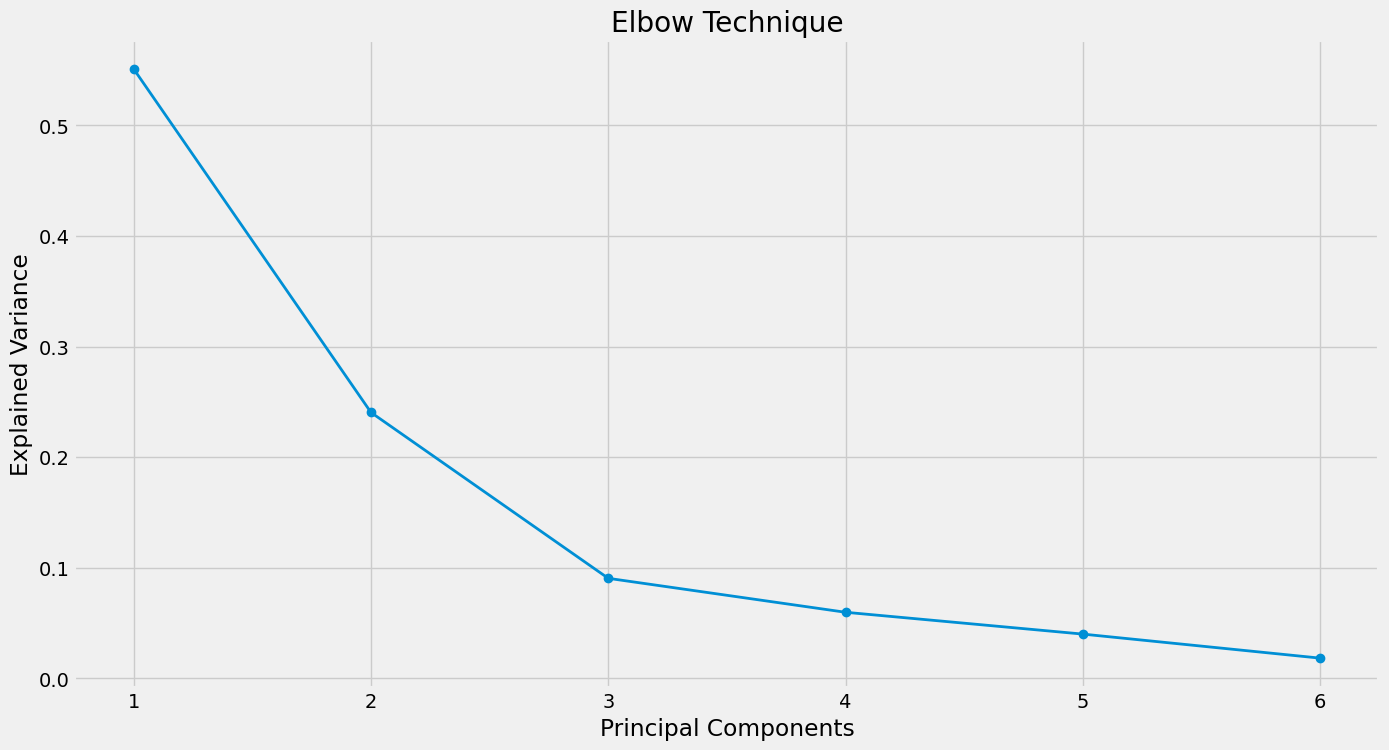

In [160]:
PCA = PrincipalComponentAnalysis()
df_pca_Filter = df_filter.copy()

values = PCA.determine_pc_explained_variance(df_pca_Filter, columns)

# Elbow Technique
plt.figure(figsize=(15, 8))
plt.plot(range(1, len(values) + 1), values, marker="o")
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance")
plt.title("Elbow Technique")
plt.show()

In [161]:
# apply pca on 3 components
df_pca_Filter = PCA.apply_pca(df_pca_Filter, columns, 3)

# apply squered root
df_squered_Filter = df_pca_Filter.copy()
Accelerometer_r = df_squered_Filter["Accelerometer_x"]**2 + df_squered_Filter["Accelerometer_y"]**2 + df_squered_Filter["Accelerometer_z"]**2
Gyroscope_r = df_squered_Filter["Gyroscope_x"]**2 + df_squered_Filter["Gyroscope_y"]**2 + df_squered_Filter["Gyroscope_z"]**2

df_squered_Filter["Accelerometer_r"] = np.sqrt(Accelerometer_r)
df_squered_Filter["Gyroscope_r"] = np.sqrt(Gyroscope_r)

### PLOT PCA & SQUERED 

<Figure size 1500x800 with 0 Axes>

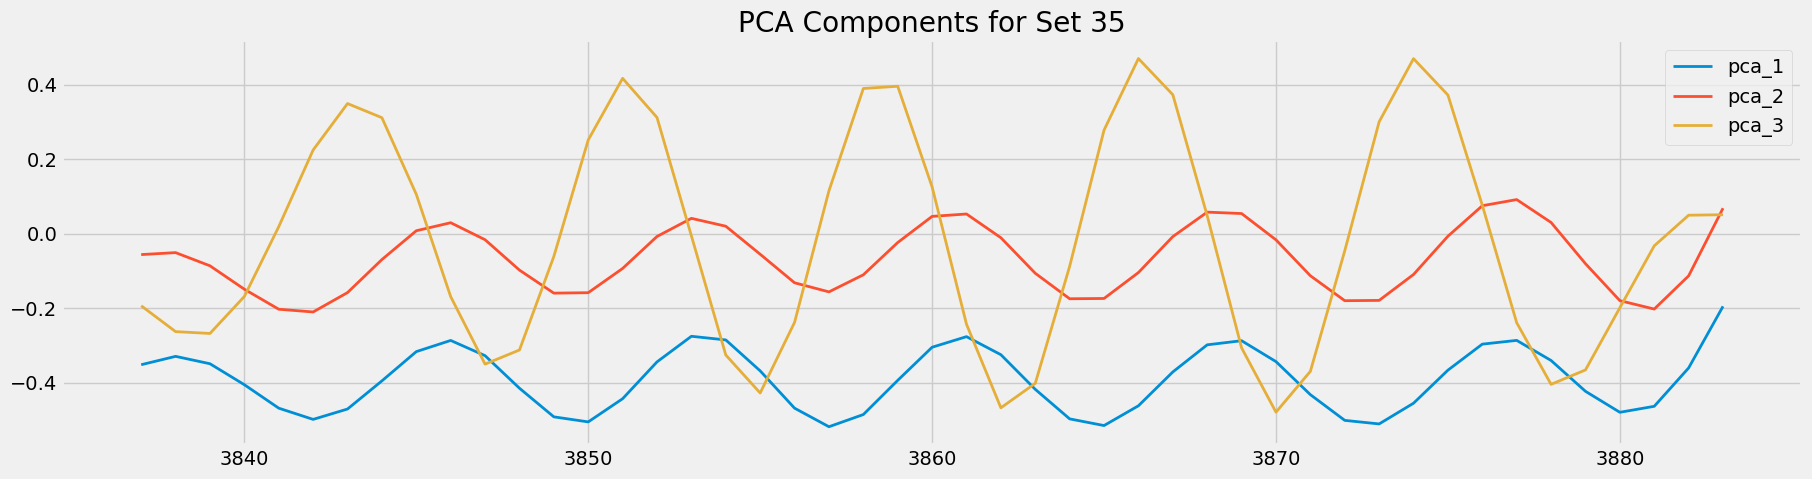

<Figure size 1500x800 with 0 Axes>

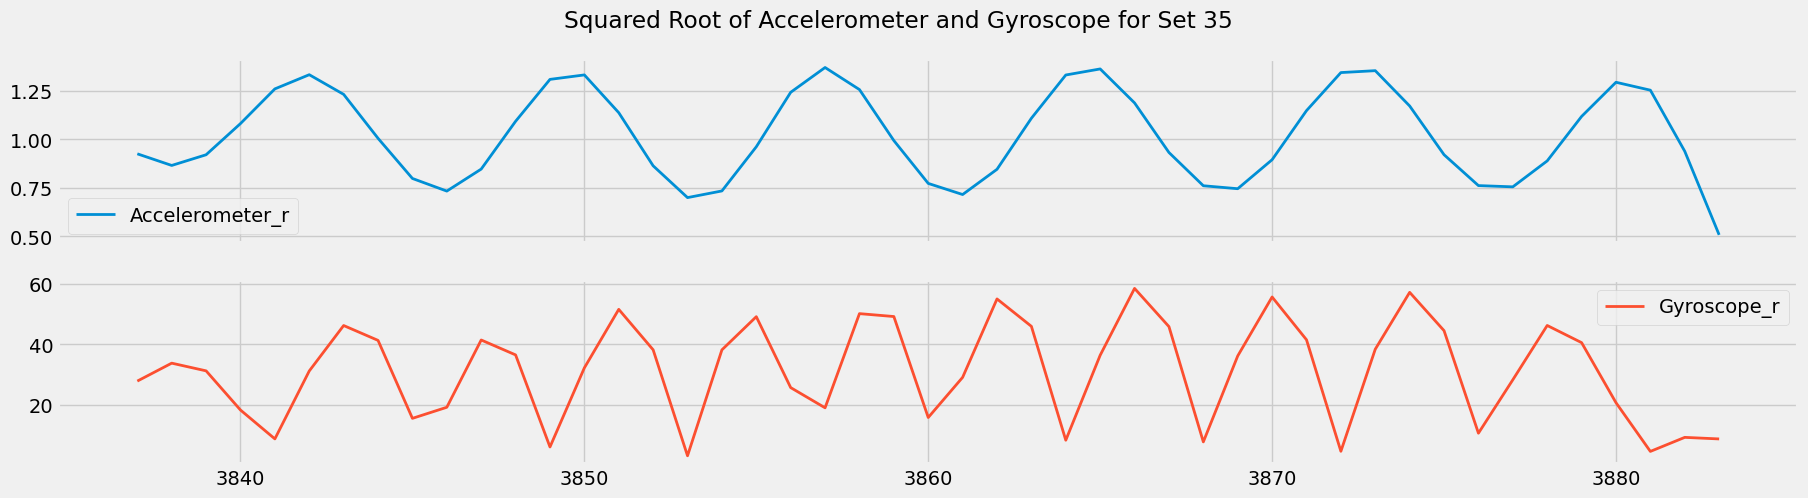

In [162]:
# PCA plot
plt.figure(figsize=(15, 8))
subset = df_pca_Filter[df_pca_Filter["Set"] == 35]
subset[["pca_1", "pca_2", "pca_3"]].plot()
plt.title("PCA Components for Set 35")
plt.show()

# Squared root plot
plt.figure(figsize=(15, 8))
subset = df_squered_Filter[df_squered_Filter["Set"] == 35]
subset[["Accelerometer_r", "Gyroscope_r"]].plot(subplots=True, layout=(2, 1))
plt.suptitle("Squared Root of Accelerometer and Gyroscope for Set 35")
plt.show()

### **CLUSTERING**

- acc_cols

In [163]:
df_cluster_Filter = df_squered_Filter.copy()
kvalues = range(1, 10)
inertia_acc = []

for k in kvalues:
    subset = df_cluster_Filter[columns_acc]
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=0)
    cluster_labels = kmeans.fit_predict(subset) # fit_predict is used to fit the model and predict the cluster labels
    inertia_acc.append(kmeans.inertia_) # inertia is the sum of squared distances of samples to their closest cluster center

# in this case is between 4 and 5 I will use 5
kmeans = KMeans(n_clusters=5, n_init=20, random_state=0)
subset = df_cluster_Filter[columns_acc]
df_cluster_Filter["cluster_acc"] = kmeans.fit_predict(subset)

- gyr_colums

In [164]:
inertia_gyr = []

for k in kvalues:
    subset = df_cluster_Filter[columns_gyro]
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=0)
    cluster_labels = kmeans.fit_predict(subset)
    inertia_gyr.append(kmeans.inertia_)

# Using elbow technique to determine the number of clusters
kmeans = KMeans(n_clusters=5, n_init=20, random_state=0)
subset = df_cluster_Filter[columns_gyro]
df_cluster_Filter["cluster_gyro"] = kmeans.fit_predict(subset)

### **PLOTS CLUSTERING**

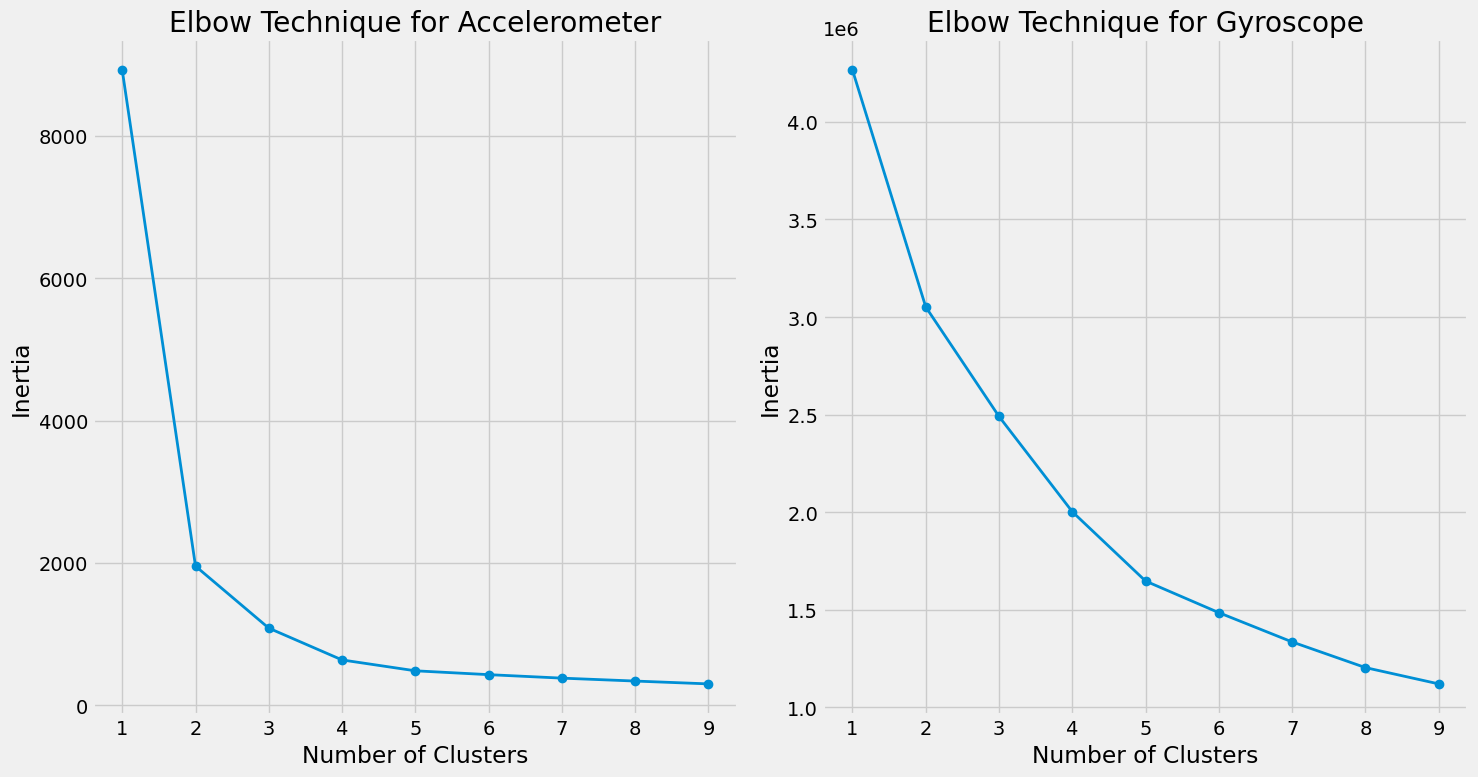

In [165]:
# Plot the elbow method for accelerometer
plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.plot(kvalues, inertia_acc, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Technique for Accelerometer")

# Plot the elbow method for gyroscope
plt.subplot(1, 2, 2)
plt.plot(kvalues, inertia_gyr, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Technique for Gyroscope")

plt.tight_layout()
plt.show()

In [166]:
df_cluster_Filter.columns

Index(['epoch (ms)', 'Accelerometer_x', 'Accelerometer_y', 'Accelerometer_z',
       'Gyroscope_x', 'Gyroscope_y', 'Gyroscope_z', 'Participants', 'Label',
       'Category', 'Set', 'pca_1', 'pca_2', 'pca_3', 'Accelerometer_r',
       'Gyroscope_r', 'cluster_acc', 'cluster_gyro'],
      dtype='object')

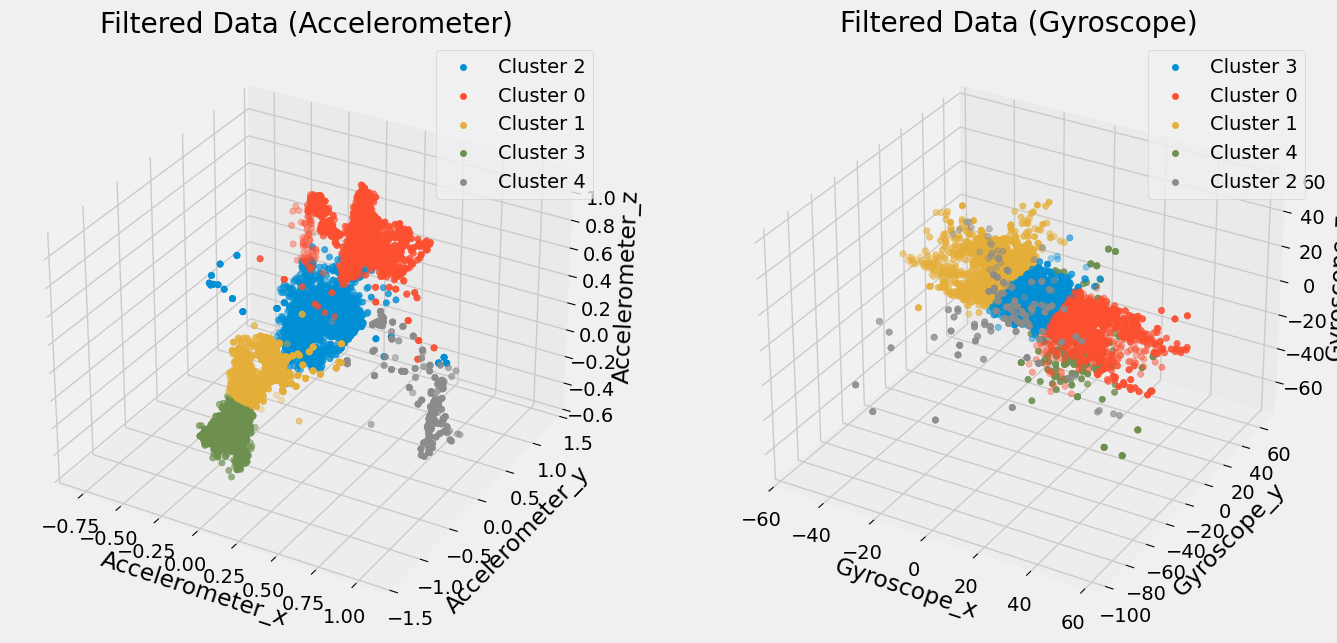

In [167]:
# plot the clusters for accelerometer
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(121, projection='3d')
for c in df_cluster_Filter["cluster_acc"].unique():
    subset = df_cluster_Filter[df_cluster_Filter["cluster_acc"] == c]
    ax.scatter(subset["Accelerometer_x"], subset["Accelerometer_y"], subset["Accelerometer_z"], label=f"Cluster {c}")
ax.set_xlabel("Accelerometer_x")
ax.set_ylabel("Accelerometer_y")
ax.set_zlabel("Accelerometer_z")
ax.set_title("Filtered Data (Accelerometer)")
plt.legend()

# plot the clusters for gyroscope
ax = fig.add_subplot(122, projection='3d')
for c in df_cluster_Filter["cluster_gyro"].unique():
    subset = df_cluster_Filter[df_cluster_Filter["cluster_gyro"] == c]
    ax.scatter(subset["Gyroscope_x"], subset["Gyroscope_y"], subset["Gyroscope_z"], label=f"Cluster {c}")
ax.set_xlabel("Gyroscope_x")
ax.set_ylabel("Gyroscope_y")
ax.set_zlabel("Gyroscope_z")
ax.set_title("Filtered Data (Gyroscope)")
plt.legend()

plt.show()

# PLOT CLUSTERING FILTER NO FILTER

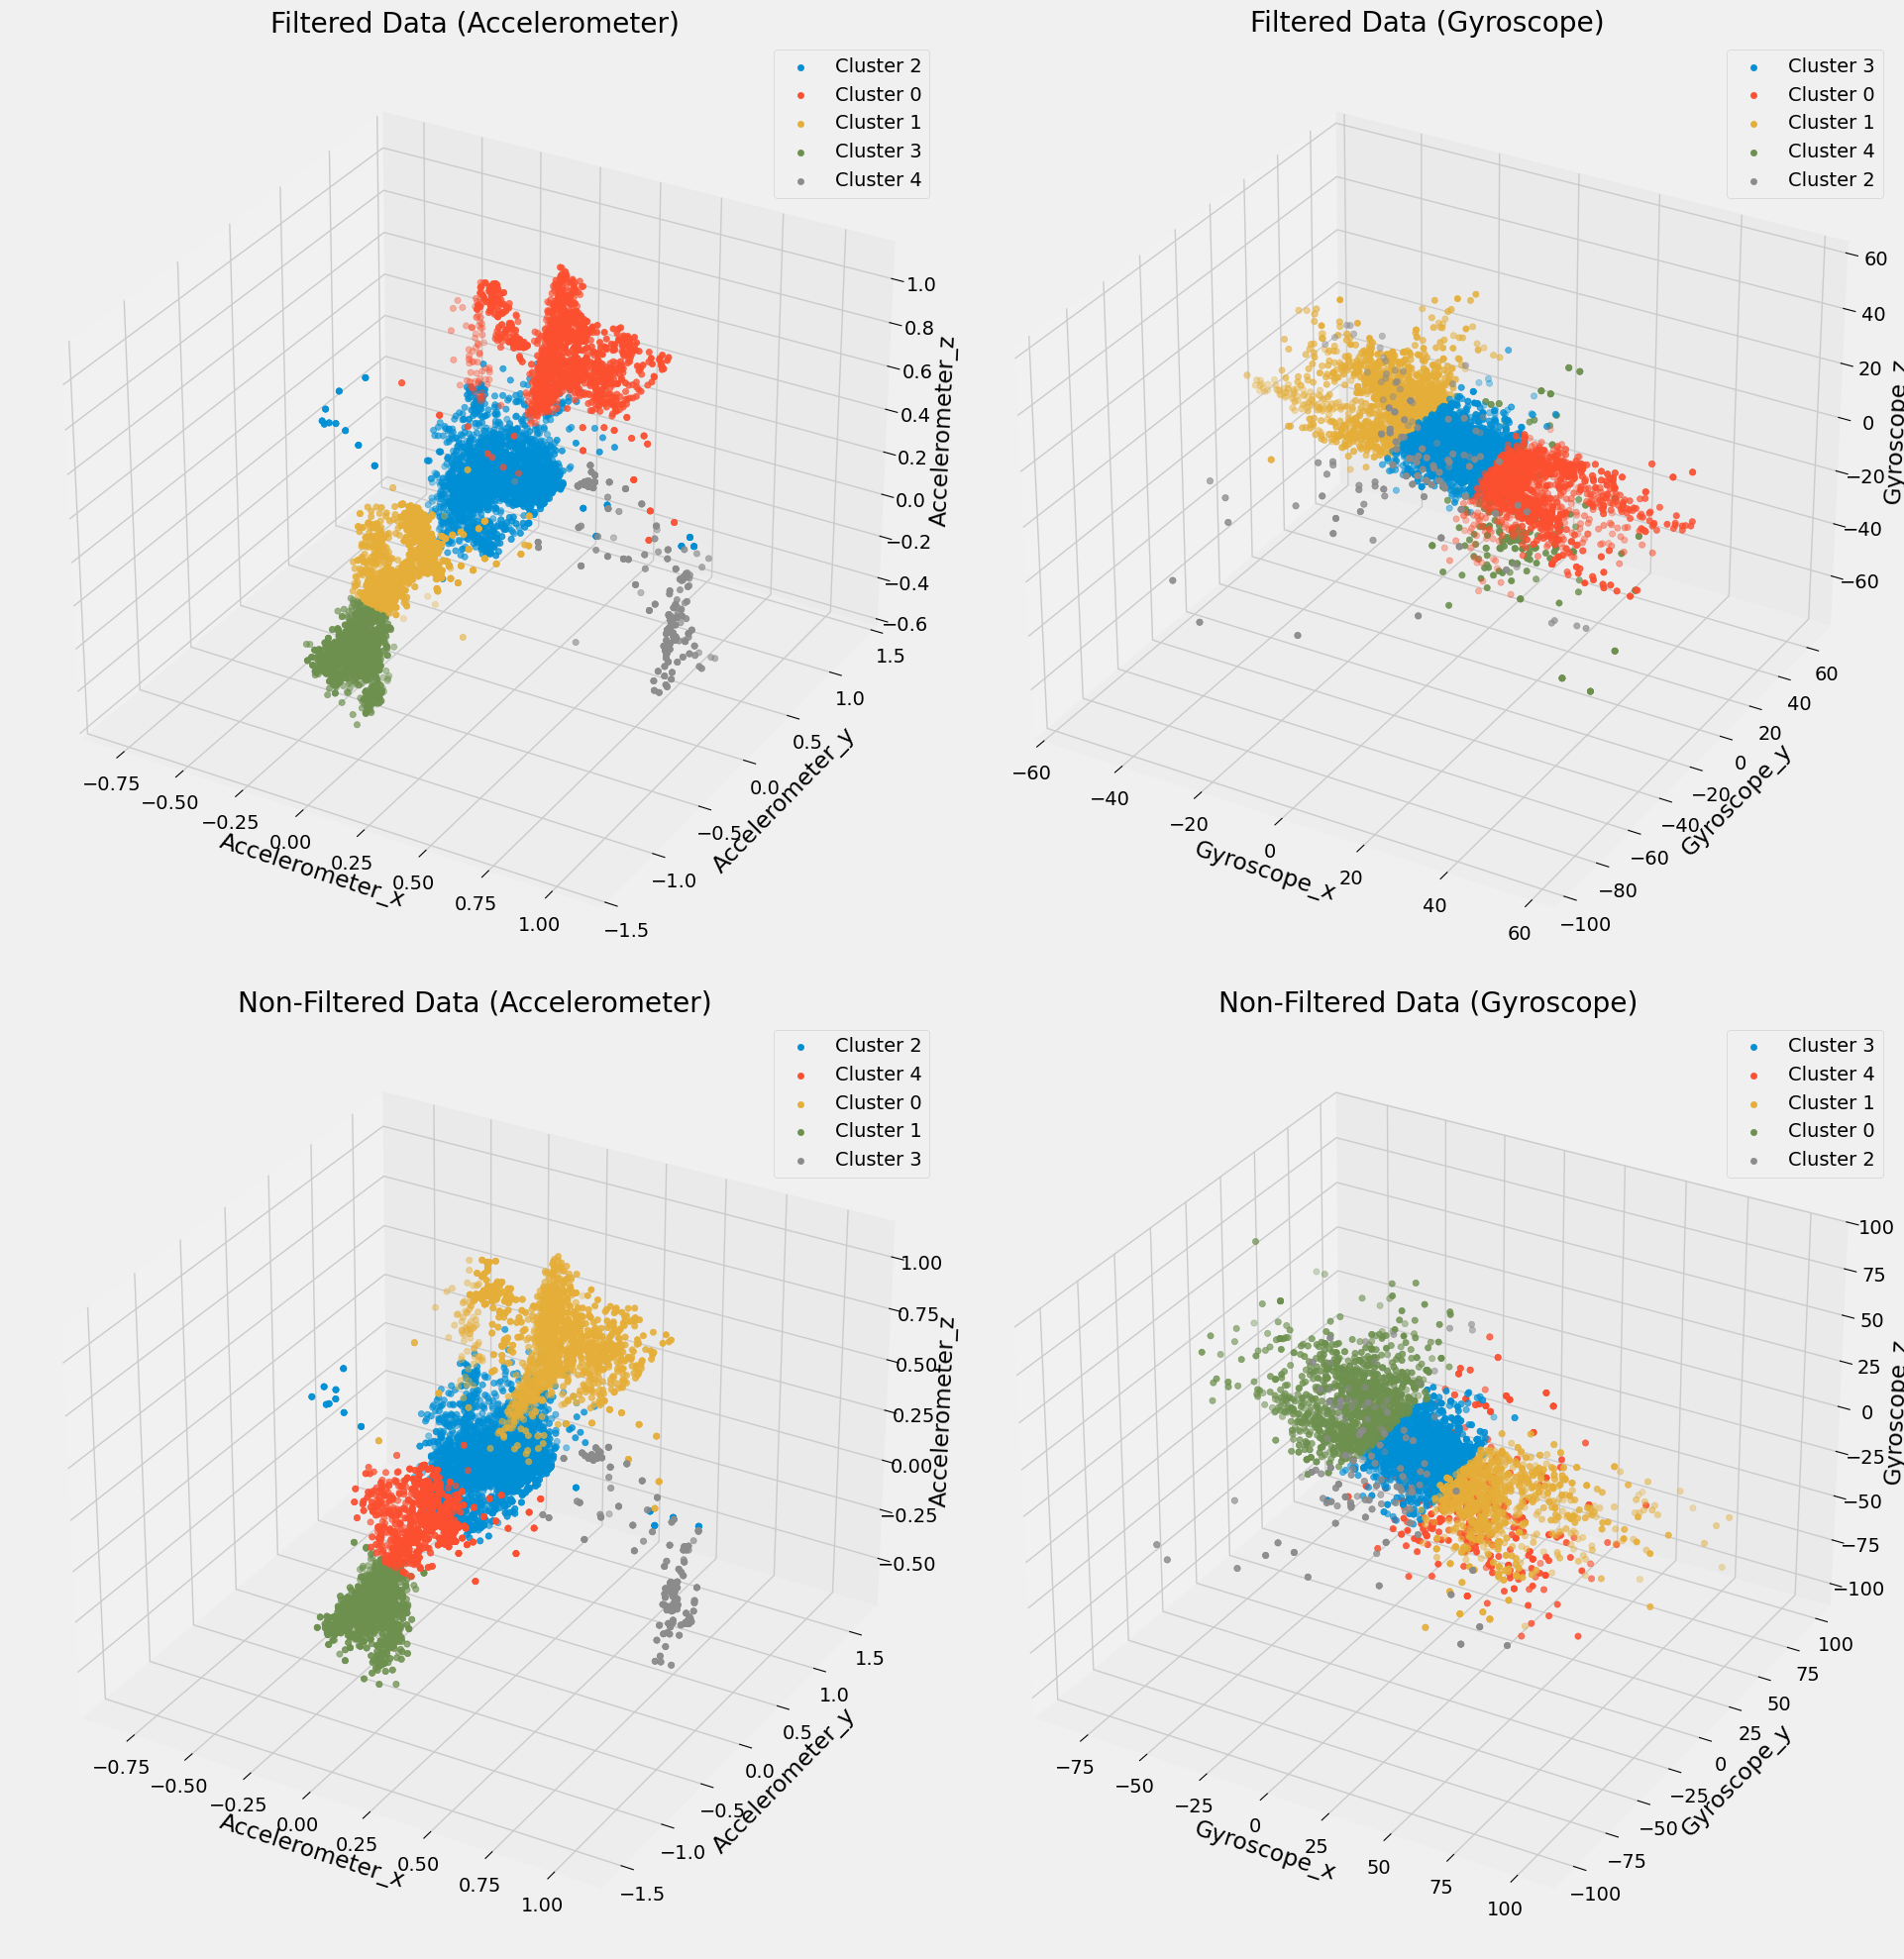

In [169]:
fig, axs = plt.subplots(2, 2, figsize=(20, 20), subplot_kw={'projection': '3d'})

# Plot the clusters for filtered data (Accelerometer)
for c in df_cluster_Filter["cluster_acc"].unique():
    subset = df_cluster_Filter[df_cluster_Filter["cluster_acc"] == c]
    axs[0, 0].scatter(subset["Accelerometer_x"], subset["Accelerometer_y"], subset["Accelerometer_z"], label=f"Cluster {c}")
axs[0, 0].set_xlabel("Accelerometer_x")
axs[0, 0].set_ylabel("Accelerometer_y")
axs[0, 0].set_zlabel("Accelerometer_z")
axs[0, 0].set_title("Filtered Data (Accelerometer)")
axs[0, 0].legend()

# Plot the clusters for filtered data (Gyroscope)
for c in df_cluster_Filter["cluster_gyro"].unique():
    subset = df_cluster_Filter[df_cluster_Filter["cluster_gyro"] == c]
    axs[0, 1].scatter(subset["Gyroscope_x"], subset["Gyroscope_y"], subset["Gyroscope_z"], label=f"Cluster {c}")
axs[0, 1].set_xlabel("Gyroscope_x")
axs[0, 1].set_ylabel("Gyroscope_y")
axs[0, 1].set_zlabel("Gyroscope_z")
axs[0, 1].set_title("Filtered Data (Gyroscope)")
axs[0, 1].legend()

# Plot the clusters for non-filtered data (Accelerometer)
for c in df_cluster_NoFilter["cluster_acc"].unique():
    subset = df_cluster_NoFilter[df_cluster_NoFilter["cluster_acc"] == c]
    axs[1, 0].scatter(subset["Accelerometer_x"], subset["Accelerometer_y"], subset["Accelerometer_z"], label=f"Cluster {c}")
axs[1, 0].set_xlabel("Accelerometer_x")
axs[1, 0].set_ylabel("Accelerometer_y")
axs[1, 0].set_zlabel("Accelerometer_z")
axs[1, 0].set_title("Non-Filtered Data (Accelerometer)")
axs[1, 0].legend()

# Plot the clusters for non-filtered data (Gyroscope)
for c in df_cluster_NoFilter["cluster_gyro"].unique():
    subset = df_cluster_NoFilter[df_cluster_NoFilter["cluster_gyro"] == c]
    axs[1, 1].scatter(subset["Gyroscope_x"], subset["Gyroscope_y"], subset["Gyroscope_z"], label=f"Cluster {c}")
axs[1, 1].set_xlabel("Gyroscope_x")
axs[1, 1].set_ylabel("Gyroscope_y")
axs[1, 1].set_zlabel("Gyroscope_z")
axs[1, 1].set_title("Non-Filtered Data (Gyroscope)")
axs[1, 1].legend()

plt.tight_layout()
plt.show()


In [ ]:
# save the dasets
#df_pca_NoFilter.to_pickle("../processed_data/dataPCA_NoFilter.pkl")
#df_pca_Filter.to_pickle("../processed_data/dataPCA_Filter.pkl")